## Position of a Quasar
In this exercise, we generate multiple measurements of a quasar’s position. These measurements are assumed to be Gaussian-distributed with homoscedastic (i.e., constant) error:
$$L \equiv p(\{x_i\}|\mu,\sigma) = \prod_{i=1}^N \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma^2}\right).$$
Our goal is to compare the value of $\mu$ that maximizes the likelihood function L with the maximum likelihood estimator (MLE), which is given by
$$\hat \mu = \frac{1}{N}\sum_{i=1}^N x_i,$$
Subsequently we want to the compare the uncertainty of $\hat \mu $, derived from the Fisher matrix, with the uncertainty of the arithmetich mean.

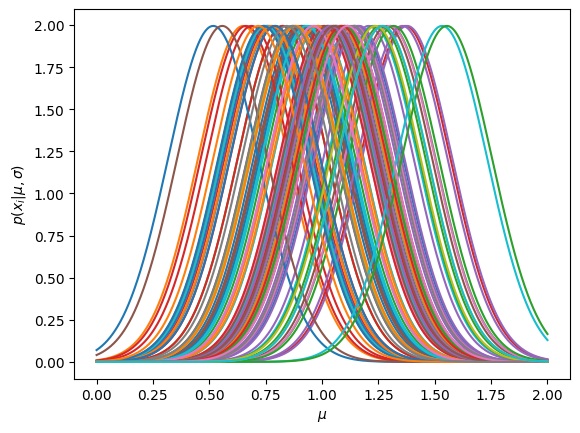

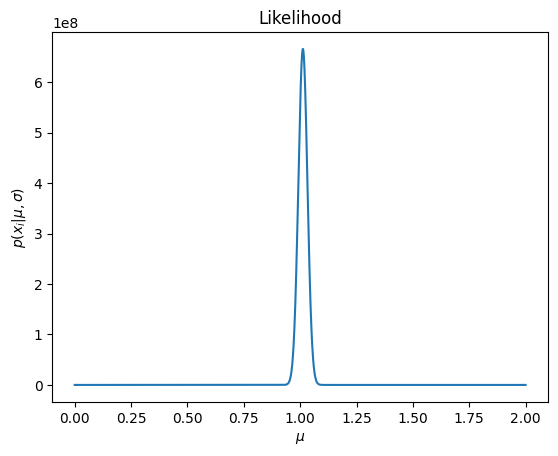

Likelihood is maximized at 1.012101210121012, the arithmetic mean is 1.0121953836873707


In [9]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm 
p= []
sigma = 0.2

x = np.linspace(0, 2,10000)

mu = norm(1, sigma).rvs(100)
N = 100
for i in range(100):
  
    #mu = np.random.normal(1,0
    gauss_arr= norm.pdf(x, mu[i], sigma)
    plt.plot(x, norm.pdf(x, mu[i], sigma))
    if i == 0:
        gauss_prod = gauss_arr
    if i != 0:
        gauss_prod = gauss_prod * gauss_arr
    plt.xlabel(r'$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$') 
  
plt.show()
#gauss_prod /= np.trapz(gauss_prod, x)
gauss_prod = gauss_prod
plt.plot(x, gauss_prod)
plt.title("Likelihood")
plt.xlabel(r'$\mu$') 
plt.ylabel(r'$p({x_i}|\mu,\sigma)$') 
plt.show()
#print("Maximized likelihood for mu : ", np.max(gauss_prod))
#fisher se faccio sdt dilog likelihood massimizzo , prim ordine zero, secondo parabola per una gaussiana fisher metric error on maximum likelihood estimator is the actual error
#se non gaauss asimptotic gaussian cioè tends to gaussian. Quindi per large set data è buon modom di estimare sigma
#se gaussiana perfec


sorted_indices = np.argsort(gauss_prod)
index_max = sorted_indices[-1]
mean = np.mean(mu)
mu_mle = x[index_max]
print(f'Likelihood is maximized at {mu_mle}, the arithmetic mean is {mean}')


Comparing the error derived from the Fisher matrix with $\frac{\sigma}{\sqrt(N)}$

In [4]:
sigma_mu = np.diff(np.log(gauss_prod), 2)
interval = ((x[1]-x[0]))**2
sigma_mu /= interval
sigma_mu *= -1
sigma_mu = 1/np.sqrt(sigma_mu[index_max]) #i have to evaluate the fisher matrix at the maximum

sigma_arit = sigma/np.sqrt(N)

print(f' The uncertainty from the Fisher matrixis {sigma_mu}, and the uncertanty of our arithmetic mean is: {sigma_arit}')

 The Fisher matrix value is 0.020000000000403986, and the uncertanty of our arithmetic mean is: 0.02


C:\Users\alexv\AppData\Local\Temp\ipykernel_9300\3515108771.py:1: RuntimeWarning: divide by zero encountered in log
  sigma_mu = np.diff(np.log(gauss_prod), 2)
C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:1515: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Comparing a normal distribuition, obtained from the product of individual likelihoods, with a gaussian located at the MLE with width $\sigma_{\mu}$, derived from the Fisher Matrix

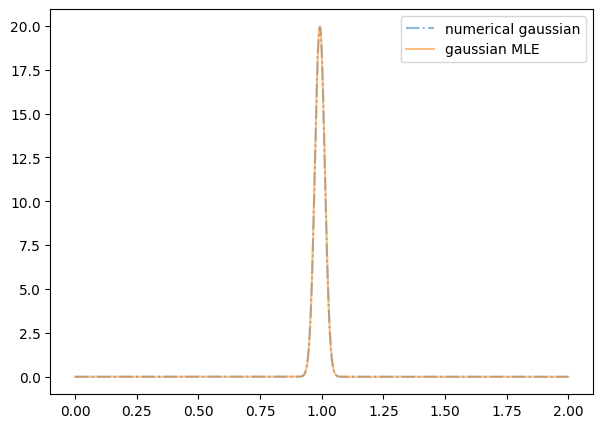

In [5]:

gauss_mle = norm.pdf(x, mu_mle, sigma_mu)
fig, ax = plt.subplots(figsize = (7,5))

C = np.max(gauss_prod)/np.max(gauss_mle)
plt.plot(x, gauss_prod/C, label= 'numerical gaussian', linestyle = '-.', alpha = 0.5)
plt.plot(x, gauss_mle, label = 'gaussian MLE', linestyle = '-', alpha = 0.5)
plt.legend()
plt.show()



In this section we repeat the analysis done above, assuming that the uncertainty associated to the measurments are heteroscedastic (i.e not constant).
Our goal is to compare the value that maximizes the likelihood L with the MLE:
$$\hat \mu = \frac{\sum_i^N (x_i/\sigma_i^2)}{\sum_i^N (1/\sigma_i^2)}$$
And analogously to the previous part, we compare the uncertainty obtained from the Fisher Matrix with 
$$\sigma_{\mu} = \left( \sum_{i=1}^N \frac{1}{\sigma_i^2}\right)^{-1/2}$$



In [12]:

N = 5
#assuming that the uncertainties follow a normal distribuition with mean 0.2 and width 0.05
sigma_ete = norm(0.2, 0.05).rvs(N)

#generate various location statistics following normal distribuition with varying width
sample_mu = np.concatenate([norm(1, err).rvs(1) for err in sigma_ete]) 
gauss_ete = np.array([norm.pdf(x, loc = sample_mu[i], scale = sigma_ete[i]) for i in range(len(sigma_ete))])
prod_ete = np.prod(gauss_ete, axis = 0)


sorted_indices = np.argsort(prod_ete)
index_max = sorted_indices[-1]
mean_ete =  np.average(sample_mu, weights = 1/sigma_ete**2)
mu_mle = x[index_max]
print(f'Likelihood is maximized at {mu_mle}, the arithmetic mean is {mean_ete}')

sigma_mu_ete = np.diff(np.log(prod_ete), 2)
interval = ((x[1]-x[0]))**2
sigma_mu_ete /= interval
sigma_mu_ete *= -1
sigma_mu_ete = 1/np.sqrt(sigma_mu_ete[index_max])
sigma_esti = (np.sum(1/sigma_ete**2))**(-0.5)
print(f'Uncertanty on MLE from Fisher matrix: {sigma_mu_ete} vs Weighted mean error:{sigma_esti}')

Likelihood is maximized at 0.8896889688968898, the arithmetic mean is 0.8896184150064116
Uncertanty on MLE from Fisher matrix: 0.07972137412072647 vs Weighted mean error:0.07972137411854249


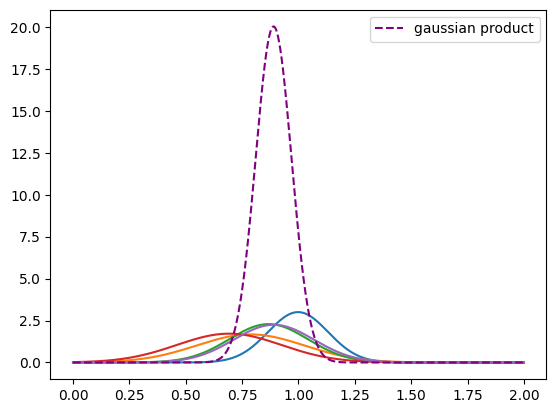

In [13]:
for like in gauss_ete:
    plt.plot(x, like)
plt.plot(x, prod_ete, color = 'purple', linestyle = '--', label = 'gaussian product')
plt.legend()
plt.show()
